In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from regex import P
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
import os


#notebook to rest reconstruction error of PCA

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch
    # np.random.seed(seed)  # Set seed for NumPy
    # random.seed(seed)  # Set seed for Python's random module

    # # If using a GPU, set seeds for CUDA as well
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # # Ensure deterministic behavior on GPU
    # torch.backends.cudnn.deterministic = True  # Make sure CUDA uses deterministic algorithms
    # torch.backends.cudnn.benchmark = False  # Avoid using CUDA's autotuning for performance (slower, but more reproducible)

# Set the seed
set_random_seeds(seed=random_seed_number)

def gen_layer_sizes(input_size,latent_size,num_layers,scaling_type = "mul"):

    """
    Generate layer sizes for a neural network based on the input size, latent size, number of layers, and scaling type.

    Args:
        input_size (int): The size of the input layer.
        latent_size (int): The size of the latent layer.
        num_layers (int): The number of layers in the network.
        scaling_type (str): The type of scaling to use. Can be "geo" or "lin".

    Returns:
        list: A list containing the sizes of each layer in the network.
    """
    if scaling_type == "mul":
        # Geometric scaling
        scale_factor = (latent_size / input_size) ** (1 / (num_layers - 1))
        layer_sizes = [int(input_size * scale_factor ** i) for i in range(num_layers)]
    elif scaling_type == "lin":
        # Linear scaling
        step = (latent_size - input_size) / (num_layers - 1)
        layer_sizes = [int(input_size + step * i) for i in range(num_layers)]
    else:
        raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

    #for torchgeodemo dont want to include the input layer
    layer_sizes = layer_sizes[1:]  # Exclude input layer size
    return layer_sizes

In [10]:
#load the cleaned data
data_name = "engcensus_all"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
df_scaled = pd.read_parquet(cleaned_data_path)
df_scaled

,OA,ts0010002,ts0010003,ts0020002,ts0020003,ts0020004,ts0020005,ts0020006,ts0020007,ts0020008,...,ts0670007,ts0670008,ts0680002,ts0680003,ts0750002,ts0750003,ts0750004,ts0750005,ts0750006,ts0750007
0,E00000001,1.000,0.000,0.209,0.595,0.546,0.472,0.074,0.049,0.0,...,0.762,0.031,0.102,0.898,0.362,0.043,0.223,0.287,0.074,0.011
1,E00000003,1.000,0.000,0.309,0.599,0.581,0.553,0.028,0.018,0.0,...,0.833,0.000,0.180,0.820,0.243,0.054,0.198,0.252,0.225,0.027
2,E00000005,1.000,0.000,0.406,0.396,0.377,0.377,0.000,0.019,0.0,...,0.830,0.000,0.047,0.953,0.413,0.032,0.190,0.254,0.063,0.048
3,E00000007,1.000,0.000,0.712,0.209,0.209,0.209,0.000,0.000,0.0,...,0.842,0.014,0.109,0.891,0.437,0.034,0.218,0.195,0.103,0.011
4,E00000010,1.000,0.000,0.772,0.170,0.170,0.158,0.012,0.000,0.0,...,0.541,0.047,0.062,0.938,0.762,0.000,0.071,0.111,0.056,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00010693,0.101,0.899,0.946,0.018,0.018,0.018,0.000,0.000,0.0,...,0.198,0.022,0.927,0.073,0.789,0.000,0.053,0.140,0.018,0.000
188876,W00010694,1.000,0.000,0.303,0.536,0.530,0.530,0.000,0.007,0.0,...,0.474,0.010,0.252,0.748,0.233,0.019,0.321,0.233,0.189,0.006
188877,W00010695,1.000,0.000,0.263,0.558,0.558,0.558,0.000,0.000,0.0,...,0.305,0.052,0.182,0.818,0.257,0.014,0.473,0.189,0.068,0.000
188878,W00010696,1.000,0.000,0.309,0.573,0.562,0.551,0.011,0.011,0.0,...,0.480,0.006,0.132,0.868,0.208,0.000,0.208,0.385,0.188,0.010


In [4]:


epochs = 250
scaling_type = "mul"
run_name = f"{epochs}epoch_scan_{scaling_type}"
WORKING_DIR = "../AE_outputs/"+data_name+"/"+run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = WORKING_DIR+ "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

bottleneck_sizes = [2,4,8,16,32,64,100,128]
input_size = len(df_scaled.columns)-1
encoder_layer_sizes = []
for bottleneck_size in bottleneck_sizes:
    encoder_layer_sizes.append(gen_layer_sizes(input_size, bottleneck_size, 4, scaling_type=scaling_type))

def plot_loss(WORKING_DIR,data_nickname,ae_nickname):
    # Load the loss data
    loss_data = pd.read_csv(WORKING_DIR + f"/logs/log_{data_nickname}_{ae_nickname}_v1/version_1/metrics.csv")[['epoch', 'train_loss_epoch', 'recon_loss_epoch']]
    #drop rows with nan
    loss_data = loss_data.dropna()
    plt.plot(loss_data["epoch"], loss_data["train_loss_epoch"], label="Training Loss")
    plt.plot(loss_data["epoch"], loss_data["recon_loss_epoch"], label="Reconstruction Loss")
    plt.show()



geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 11, 69]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [69, 11, 2]}, 'max_epochs': 250, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [2, 11, 69, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=69, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=69, out_features=11, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=11, out_features=2, bias=True)
    

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 29.0 K | train
2 | decoder       | MLP     | 29.4 K | train
--------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
5

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 47.91it/s, v_num=0_1, recon_loss_step=0.0279, train_loss_step=0.0279, recon_loss_epoch=0.028, train_loss_epoch=0.028]  

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 47.64it/s, v_num=0_1, recon_loss_step=0.0279, train_loss_step=0.0279, recon_loss_epoch=0.028, train_loss_epoch=0.028]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_2_v1__reconstructed_outputs.csv


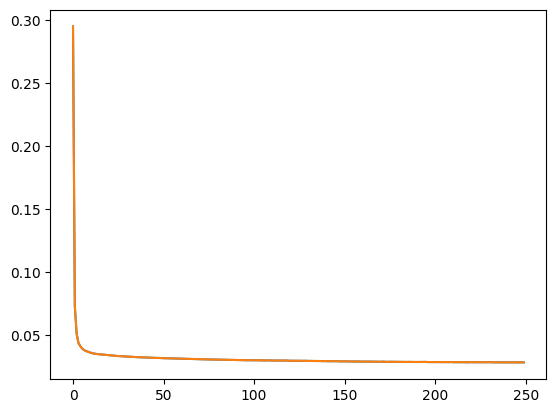


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 18, 87]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [87, 18, 4]}, 'max_epochs': 250, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [4, 18, 87, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=87, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=87, out_features=18, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=18, out_features=4, bias=True)
    

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.2 K | train
2 | decoder       | MLP     | 37.6 K | train
--------------------------------------------------
74.9 K    Trainable params
0         Non-trainable params
74.9 K    Total params
0.300     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 48.65it/s, v_num=0_1, recon_loss_step=0.0188, train_loss_step=0.0188, recon_loss_epoch=0.019, train_loss_epoch=0.019]  

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 48.39it/s, v_num=0_1, recon_loss_step=0.0188, train_loss_step=0.0188, recon_loss_epoch=0.019, train_loss_epoch=0.019]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_4_v1__reconstructed_outputs.csv


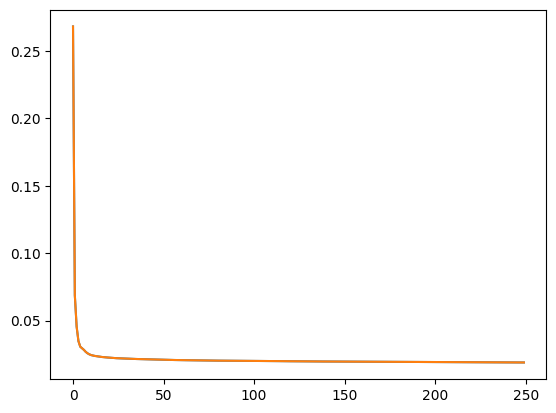


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 29, 110]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [110, 29, 8]}, 'max_epochs': 250, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [8, 29, 110, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=110, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=110, out_features=29, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=29, out_features=8, bias=True)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 48.4 K | train
2 | decoder       | MLP     | 48.8 K | train
--------------------------------------------------
97.3 K    Trainable params
0         Non-trainable params
97.3 K    Total params
0.389     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 41.83it/s, v_num=0_1, recon_loss_step=0.0114, train_loss_step=0.0114, recon_loss_epoch=0.0117, train_loss_epoch=0.0117]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 41.65it/s, v_num=0_1, recon_loss_step=0.0114, train_loss_step=0.0114, recon_loss_epoch=0.0117, train_loss_epoch=0.0117]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_8_v1__reconstructed_outputs.csv


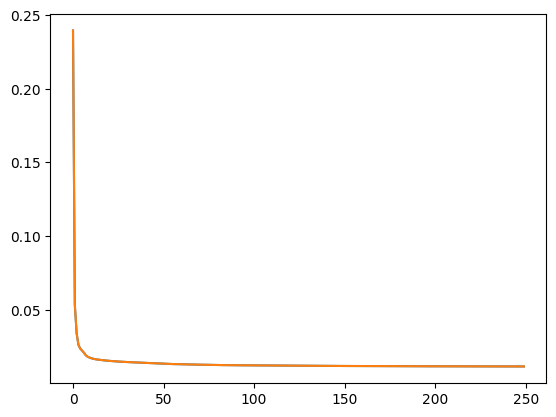


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 47, 138]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [138, 47, 16]}, 'max_epochs': 250, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [16, 47, 138, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=138, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=138, out_features=47, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=47, out_features=16, bias=

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 63.7 K | train
2 | decoder       | MLP     | 64.1 K | train
--------------------------------------------------
127 K     Trainable params
0         Non-trainable params
127 K     Total params
0.512     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.37it/s, v_num=0_1, recon_loss_step=0.00718, train_loss_step=0.00718, recon_loss_epoch=0.00728, train_loss_epoch=0.00728]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.13it/s, v_num=0_1, recon_loss_step=0.00718, train_loss_step=0.00718, recon_loss_epoch=0.00728, train_loss_epoch=0.00728]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_16_v1__reconstructed_outputs.csv


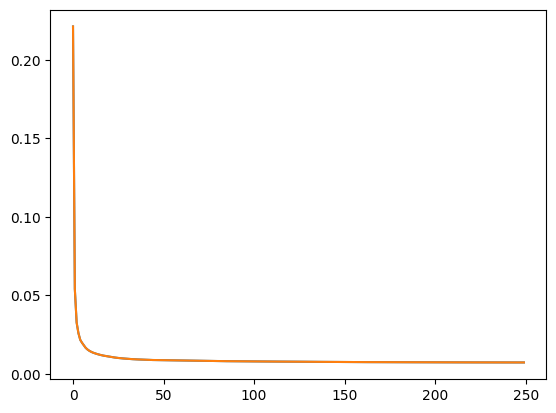


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 74, 174]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [174, 74, 32]}, 'max_epochs': 250, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 74, 174, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=174, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=174, out_features=74, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=74, out_features=32, bias=

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 86.5 K | train
2 | decoder       | MLP     | 86.9 K | train
--------------------------------------------------
173 K     Trainable params
0         Non-trainable params
173 K     Total params
0.694     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 34.15it/s, v_num=0_1, recon_loss_step=0.00405, train_loss_step=0.00405, recon_loss_epoch=0.00412, train_loss_epoch=0.00412]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 33.85it/s, v_num=0_1, recon_loss_step=0.00405, train_loss_step=0.00405, recon_loss_epoch=0.00412, train_loss_epoch=0.00412]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_32_v1__reconstructed_outputs.csv


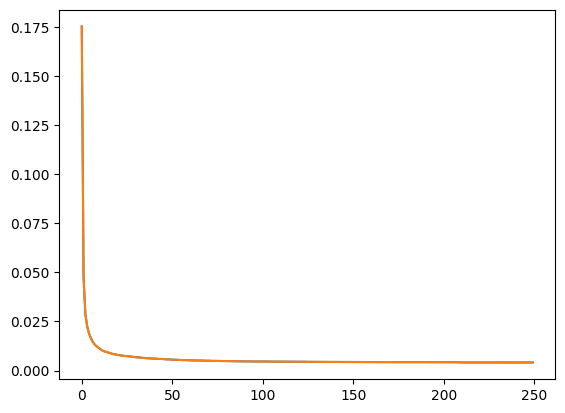


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [63, 118, 220]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [220, 118, 63]}, 'max_epochs': 250, 'nickname': 'bottleneck_63', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [63, 118, 220, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=220, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=220, out_features=118, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=118, out_features=63, 

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 123 K  | train
2 | decoder       | MLP     | 123 K  | train
--------------------------------------------------
247 K     Trainable params
0         Non-trainable params
247 K     Total params
0.990     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.76it/s, v_num=0_1, recon_loss_step=0.00203, train_loss_step=0.00203, recon_loss_epoch=0.00206, train_loss_epoch=0.00206]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.40it/s, v_num=0_1, recon_loss_step=0.00203, train_loss_step=0.00203, recon_loss_epoch=0.00206, train_loss_epoch=0.00206]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_63_v1__reconstructed_outputs.csv


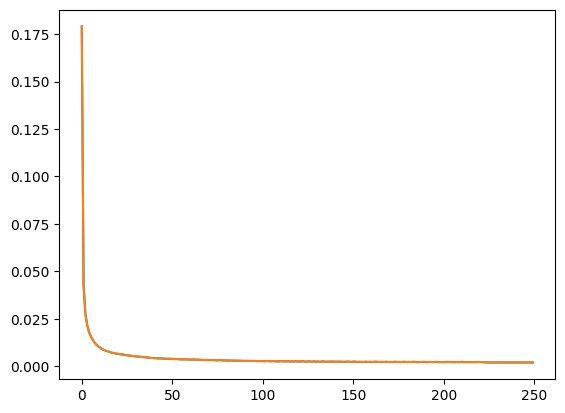


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [99, 159, 255]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [255, 159, 99]}, 'max_epochs': 250, 'nickname': 'bottleneck_99', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [99, 159, 255, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=255, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=255, out_features=159, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=159, out_features=99, 

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 160 K  | train
2 | decoder       | MLP     | 161 K  | train
--------------------------------------------------
321 K     Trainable params
0         Non-trainable params
321 K     Total params
1.288     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 36.86it/s, v_num=0_1, recon_loss_step=0.00132, train_loss_step=0.00132, recon_loss_epoch=0.00133, train_loss_epoch=0.00133]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 36.62it/s, v_num=0_1, recon_loss_step=0.00132, train_loss_step=0.00132, recon_loss_epoch=0.00133, train_loss_epoch=0.00133]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_99_v1__reconstructed_outputs.csv


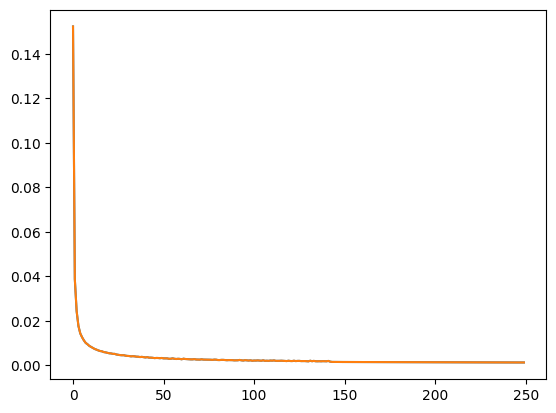


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 188, 277]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [277, 188, 128]}, 'max_epochs': 250, 'nickname': 'bottleneck_128', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [128, 188, 277, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=277, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=277, out_features=188, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=188, out_features=

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 189 K  | train
2 | decoder       | MLP     | 190 K  | train
--------------------------------------------------
379 K     Trainable params
0         Non-trainable params
379 K     Total params
1.519     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 40.33it/s, v_num=0_1, recon_loss_step=0.001, train_loss_step=0.001, recon_loss_epoch=0.00101, train_loss_epoch=0.00101]      

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 39.89it/s, v_num=0_1, recon_loss_step=0.001, train_loss_step=0.001, recon_loss_epoch=0.00101, train_loss_epoch=0.00101]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo__bottleneck_128_v1__reconstructed_outputs.csv


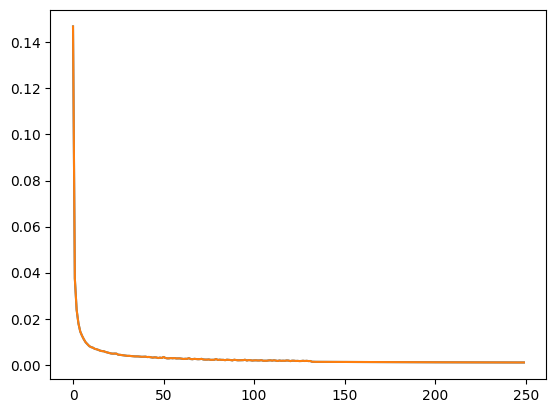

In [5]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        },
        "decoder": {
            "sizes":  "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}

data_nickname = "census_geodemo"
# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 11, 69]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [69, 11, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 250, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'use_covariance_loss': False, 'decoder_sizes': [2, 11, 69, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=69, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=69, out_features=11, bias

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 29.0 K | train
2 | decoder       | MLP     | 29.4 K | train
--------------------------------------------------
58.4 K    Trainable params
0         Non-trainable params
58.4 K    Total params
0.234     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 34.99it/s, v_num=0_1, recon_loss_step=0.0391, sparsity_loss_step=0.0184, train_loss_step=0.0392, recon_loss_epoch=0.0392, sparsity_loss_epoch=0.0189, train_loss_epoch=0.0394]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 34.84it/s, v_num=0_1, recon_loss_step=0.0391, sparsity_loss_step=0.0184, train_loss_step=0.0392, recon_loss_epoch=0.0392, sparsity_loss_epoch=0.0189, train_loss_epoch=0.0394]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_2_v1__reconstructed_outputs.csv


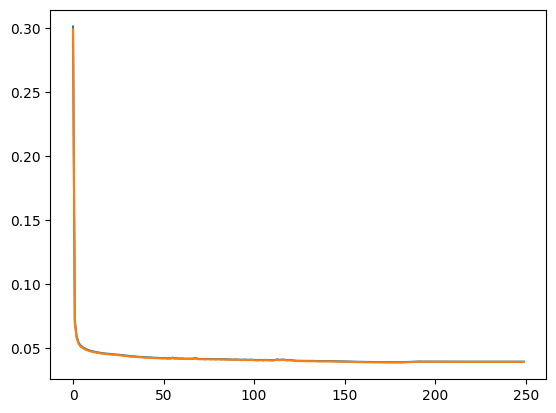


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 18, 87]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [87, 18, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 250, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'use_covariance_loss': False, 'decoder_sizes': [4, 18, 87, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=87, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=87, out_features=18, bias

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.2 K | train
2 | decoder       | MLP     | 37.6 K | train
--------------------------------------------------
74.9 K    Trainable params
0         Non-trainable params
74.9 K    Total params
0.300     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 42.69it/s, v_num=0_1, recon_loss_step=0.0329, sparsity_loss_step=0.0487, train_loss_step=0.0334, recon_loss_epoch=0.0332, sparsity_loss_epoch=0.048, train_loss_epoch=0.0336] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 42.44it/s, v_num=0_1, recon_loss_step=0.0329, sparsity_loss_step=0.0487, train_loss_step=0.0334, recon_loss_epoch=0.0332, sparsity_loss_epoch=0.048, train_loss_epoch=0.0336]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_4_v1__reconstructed_outputs.csv


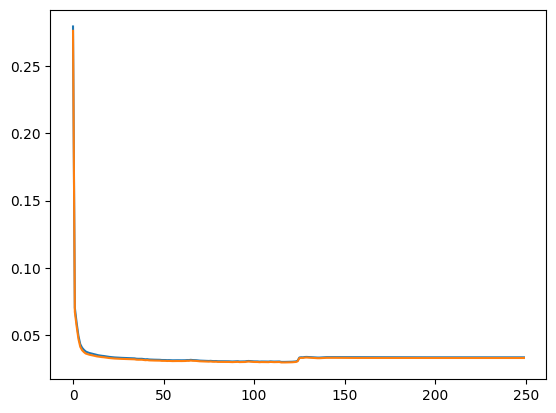


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 29, 110]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [110, 29, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 250, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'use_covariance_loss': False, 'decoder_sizes': [8, 29, 110, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=110, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=110, out_features=29,

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 48.4 K | train
2 | decoder       | MLP     | 48.8 K | train
--------------------------------------------------
97.3 K    Trainable params
0         Non-trainable params
97.3 K    Total params
0.389     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.38it/s, v_num=0_1, recon_loss_step=0.0178, sparsity_loss_step=0.0269, train_loss_step=0.018, recon_loss_epoch=0.0181, sparsity_loss_epoch=0.0269, train_loss_epoch=0.0184] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 43.16it/s, v_num=0_1, recon_loss_step=0.0178, sparsity_loss_step=0.0269, train_loss_step=0.018, recon_loss_epoch=0.0181, sparsity_loss_epoch=0.0269, train_loss_epoch=0.0184]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_8_v1__reconstructed_outputs.csv


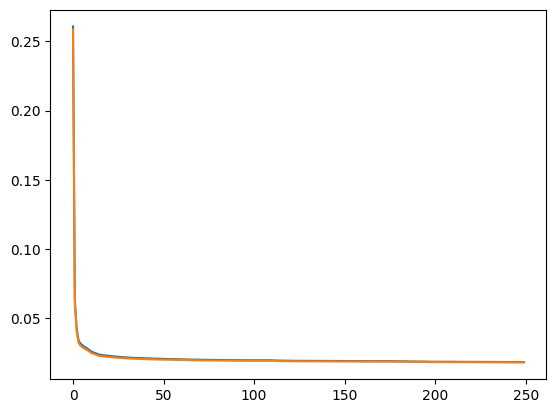


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 47, 138]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [138, 47, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 250, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'use_covariance_loss': False, 'decoder_sizes': [16, 47, 138, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=138, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=138, out_features

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 63.7 K | train
2 | decoder       | MLP     | 64.1 K | train
--------------------------------------------------
127 K     Trainable params
0         Non-trainable params
127 K     Total params
0.512     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 40.71it/s, v_num=0_1, recon_loss_step=0.0104, sparsity_loss_step=0.0253, train_loss_step=0.0107, recon_loss_epoch=0.0106, sparsity_loss_epoch=0.0252, train_loss_epoch=0.0108]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 40.47it/s, v_num=0_1, recon_loss_step=0.0104, sparsity_loss_step=0.0253, train_loss_step=0.0107, recon_loss_epoch=0.0106, sparsity_loss_epoch=0.0252, train_loss_epoch=0.0108]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_16_v1__reconstructed_outputs.csv


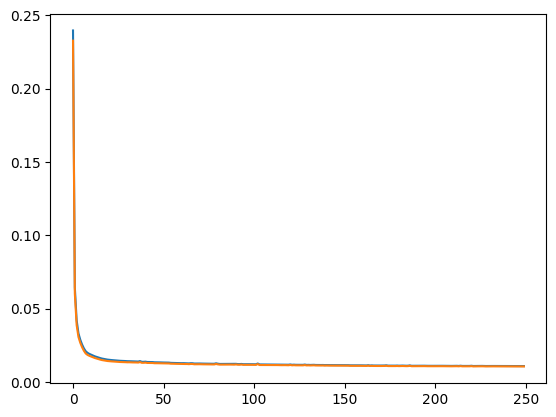


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 74, 174]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [174, 74, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 250, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'use_covariance_loss': False, 'decoder_sizes': [32, 74, 174, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=174, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=174, out_featur

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 86.5 K | train
2 | decoder       | MLP     | 86.9 K | train
--------------------------------------------------
173 K     Trainable params
0         Non-trainable params
173 K     Total params
0.694     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 40.58it/s, v_num=0_1, recon_loss_step=0.00658, sparsity_loss_step=0.0313, train_loss_step=0.00689, recon_loss_epoch=0.0067, sparsity_loss_epoch=0.0318, train_loss_epoch=0.00701] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 40.32it/s, v_num=0_1, recon_loss_step=0.00658, sparsity_loss_step=0.0313, train_loss_step=0.00689, recon_loss_epoch=0.0067, sparsity_loss_epoch=0.0318, train_loss_epoch=0.00701]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_32_v1__reconstructed_outputs.csv


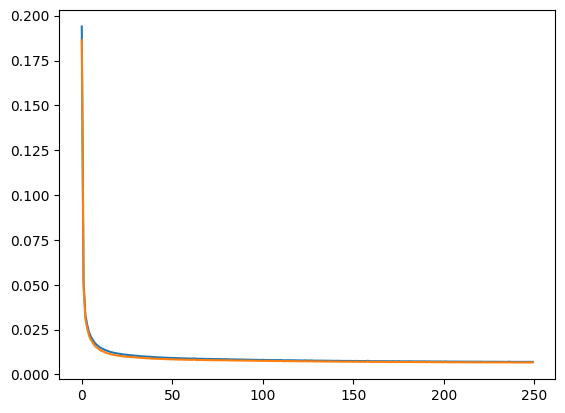


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [63, 118, 220]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [220, 118, 63], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 31}}, 'max_epochs': 250, 'nickname': 'bottleneck_63', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 31, 'use_covariance_loss': False, 'decoder_sizes': [63, 118, 220, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=220, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=220, out_fea

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 123 K  | train
2 | decoder       | MLP     | 123 K  | train
--------------------------------------------------
247 K     Trainable params
0         Non-trainable params
247 K     Total params
0.990     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 35.38it/s, v_num=0_1, recon_loss_step=0.00401, sparsity_loss_step=0.0377, train_loss_step=0.00439, recon_loss_epoch=0.00406, sparsity_loss_epoch=0.0376, train_loss_epoch=0.00444]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 35.08it/s, v_num=0_1, recon_loss_step=0.00401, sparsity_loss_step=0.0377, train_loss_step=0.00439, recon_loss_epoch=0.00406, sparsity_loss_epoch=0.0376, train_loss_epoch=0.00444]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_63_v1__reconstructed_outputs.csv


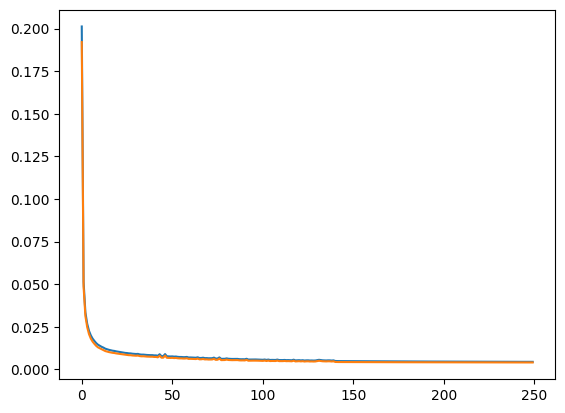


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [99, 159, 255]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [255, 159, 99], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 49}}, 'max_epochs': 250, 'nickname': 'bottleneck_99', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 49, 'use_covariance_loss': False, 'decoder_sizes': [99, 159, 255, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=255, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=255, out_fea

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 160 K  | train
2 | decoder       | MLP     | 161 K  | train
--------------------------------------------------
321 K     Trainable params
0         Non-trainable params
321 K     Total params
1.288     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 27.54it/s, v_num=0_1, recon_loss_step=0.00311, sparsity_loss_step=0.0471, train_loss_step=0.00358, recon_loss_epoch=0.00328, sparsity_loss_epoch=0.0468, train_loss_epoch=0.00375]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 27.36it/s, v_num=0_1, recon_loss_step=0.00311, sparsity_loss_step=0.0471, train_loss_step=0.00358, recon_loss_epoch=0.00328, sparsity_loss_epoch=0.0468, train_loss_epoch=0.00375]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_99_v1__reconstructed_outputs.csv


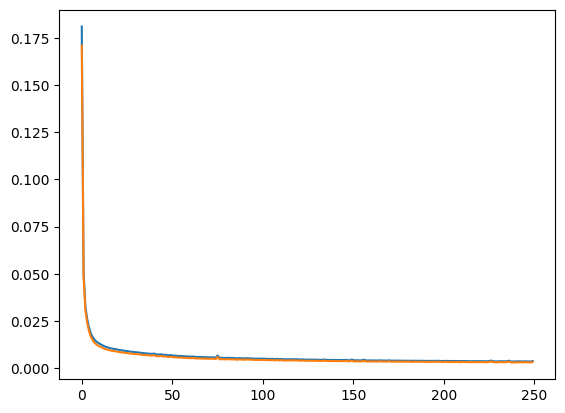


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 188, 277]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [277, 188, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 250, 'nickname': 'bottleneck_128', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/census_data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../AE_outputs/engcensus_all/250epoch_scan_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 188, 277, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=277, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=277, out

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 189 K  | train
2 | decoder       | MLP     | 190 K  | train
--------------------------------------------------
379 K     Trainable params
0         Non-trainable params
379 K     Total params
1.519     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 28.35it/s, v_num=0_1, recon_loss_step=0.00263, sparsity_loss_step=0.0483, train_loss_step=0.00311, recon_loss_epoch=0.00273, sparsity_loss_epoch=0.0486, train_loss_epoch=0.00321]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 27.92it/s, v_num=0_1, recon_loss_step=0.00263, sparsity_loss_step=0.0483, train_loss_step=0.00311, recon_loss_epoch=0.00273, sparsity_loss_epoch=0.0486, train_loss_epoch=0.00321]
Reconstructed outputs saved to ../AE_outputs/engcensus_all/250epoch_scan_mul/census_geodemo_sparse__bottleneck_128_v1__reconstructed_outputs.csv


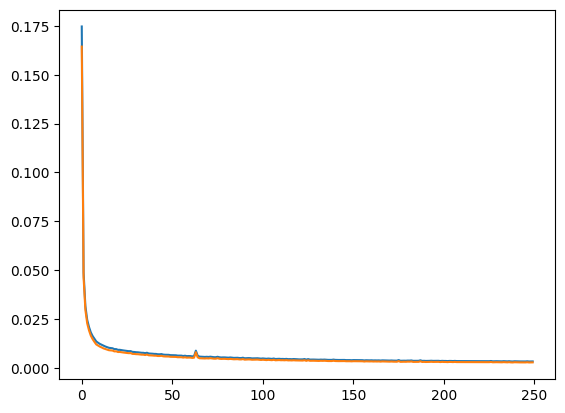

In [6]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparse"

# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 137, 272]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [272, 137, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 250, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'decoder_sizes': [2, 137, 272, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=272, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=272, out_features=137, bias=True)
      (3): LeakyReLU

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 148 K  | train
2 | decoder       | MLP     | 149 K  | train
--------------------------------------------------
298 K     Trainable params
0         Non-trainable params
298 K     Total params
1.193     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 37.91it/s, v_num=0_1, recon_loss_step=0.659, covariance_loss_step=8.83e-5, sparsity_loss_step=0.0301, train_loss_step=0.659, recon_loss_epoch=0.659, covariance_loss_epoch=0.000513, sparsity_loss_epoch=0.0281, train_loss_epoch=0.660]     

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 37.61it/s, v_num=0_1, recon_loss_step=0.659, covariance_loss_step=8.83e-5, sparsity_loss_step=0.0301, train_loss_step=0.659, recon_loss_epoch=0.659, covariance_loss_epoch=0.000513, sparsity_loss_epoch=0.0281, train_loss_epoch=0.660]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_2_v1__reconstructed_outputs.csv


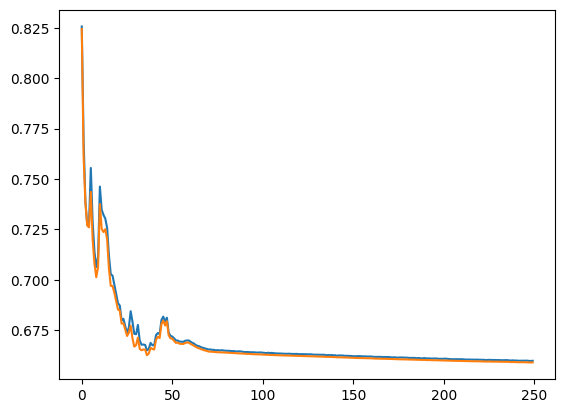


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 138, 273]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [273, 138, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 250, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'decoder_sizes': [4, 138, 273, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=273, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=273, out_features=138, bias=True)
      (3): LeakyReLU

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 150 K  | train
2 | decoder       | MLP     | 150 K  | train
--------------------------------------------------
300 K     Trainable params
0         Non-trainable params
300 K     Total params
1.202     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 38.33it/s, v_num=0_1, recon_loss_step=0.567, covariance_loss_step=0.00323, sparsity_loss_step=0.0206, train_loss_step=0.571, recon_loss_epoch=0.567, covariance_loss_epoch=0.00401, sparsity_loss_epoch=0.0205, train_loss_epoch=0.571]    

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 38.06it/s, v_num=0_1, recon_loss_step=0.567, covariance_loss_step=0.00323, sparsity_loss_step=0.0206, train_loss_step=0.571, recon_loss_epoch=0.567, covariance_loss_epoch=0.00401, sparsity_loss_epoch=0.0205, train_loss_epoch=0.571]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_4_v1__reconstructed_outputs.csv


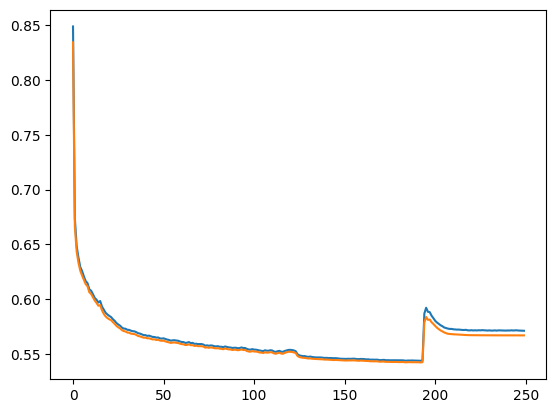


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 141, 274]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [274, 141, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 250, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'decoder_sizes': [8, 141, 274, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=274, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=274, out_features=141, bias=True)
      (3): LeakyReLU

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 151 K  | train
2 | decoder       | MLP     | 152 K  | train
--------------------------------------------------
304 K     Trainable params
0         Non-trainable params
304 K     Total params
1.217     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 35.84it/s, v_num=0_1, recon_loss_step=0.476, covariance_loss_step=0.00147, sparsity_loss_step=0.0295, train_loss_step=0.478, recon_loss_epoch=0.481, covariance_loss_epoch=0.00145, sparsity_loss_epoch=0.029, train_loss_epoch=0.483]    

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 35.55it/s, v_num=0_1, recon_loss_step=0.476, covariance_loss_step=0.00147, sparsity_loss_step=0.0295, train_loss_step=0.478, recon_loss_epoch=0.481, covariance_loss_epoch=0.00145, sparsity_loss_epoch=0.029, train_loss_epoch=0.483]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_8_v1__reconstructed_outputs.csv


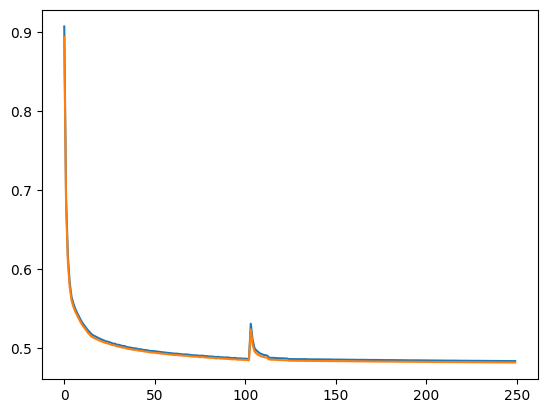


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 146, 277]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [277, 146, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 250, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'decoder_sizes': [16, 146, 277, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=277, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=277, out_features=146, bias=True)
      (3): Leaky

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 156 K  | train
2 | decoder       | MLP     | 156 K  | train
--------------------------------------------------
312 K     Trainable params
0         Non-trainable params
312 K     Total params
1.251     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 39.62it/s, v_num=0_1, recon_loss_step=0.408, covariance_loss_step=0.00129, sparsity_loss_step=0.0384, train_loss_step=0.410, recon_loss_epoch=0.415, covariance_loss_epoch=0.00122, sparsity_loss_epoch=0.0388, train_loss_epoch=0.416] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 39.29it/s, v_num=0_1, recon_loss_step=0.408, covariance_loss_step=0.00129, sparsity_loss_step=0.0384, train_loss_step=0.410, recon_loss_epoch=0.415, covariance_loss_epoch=0.00122, sparsity_loss_epoch=0.0388, train_loss_epoch=0.416]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_16_v1__reconstructed_outputs.csv


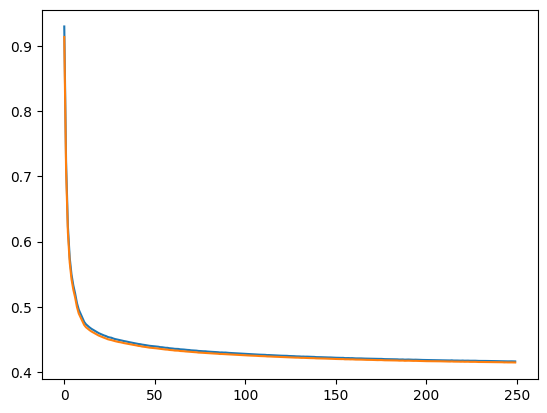


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 157, 282]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [282, 157, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 250, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'decoder_sizes': [32, 157, 282, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=282, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=282, out_features=157, bias=True)
      (3): Lea

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 164 K  | train
2 | decoder       | MLP     | 165 K  | train
--------------------------------------------------
330 K     Trainable params
0         Non-trainable params
330 K     Total params
1.320     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 38.10it/s, v_num=0_1, recon_loss_step=0.353, covariance_loss_step=0.00154, sparsity_loss_step=0.0469, train_loss_step=0.355, recon_loss_epoch=0.353, covariance_loss_epoch=0.00177, sparsity_loss_epoch=0.0471, train_loss_epoch=0.355]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 37.84it/s, v_num=0_1, recon_loss_step=0.353, covariance_loss_step=0.00154, sparsity_loss_step=0.0469, train_loss_step=0.355, recon_loss_epoch=0.353, covariance_loss_epoch=0.00177, sparsity_loss_epoch=0.0471, train_loss_epoch=0.355]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_32_v1__reconstructed_outputs.csv


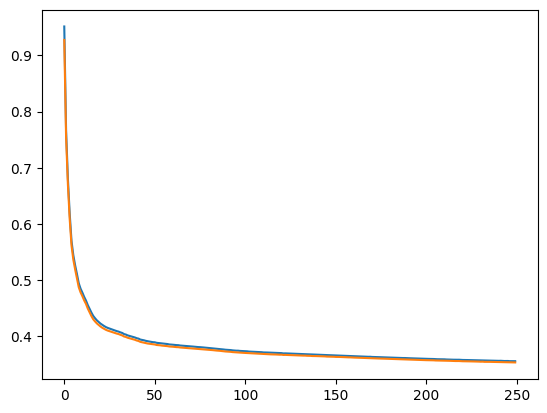


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 178, 293]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [293, 178, 64], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 250, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'decoder_sizes': [64, 178, 293, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=293, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=293, out_features=178, bias=True)
      (3): Lea

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 183 K  | train
2 | decoder       | MLP     | 183 K  | train
--------------------------------------------------
367 K     Trainable params
0         Non-trainable params
367 K     Total params
1.470     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 34.07it/s, v_num=0_1, recon_loss_step=0.297, covariance_loss_step=0.00311, sparsity_loss_step=0.0636, train_loss_step=0.300, recon_loss_epoch=0.294, covariance_loss_epoch=0.00296, sparsity_loss_epoch=0.0636, train_loss_epoch=0.298]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 33.83it/s, v_num=0_1, recon_loss_step=0.297, covariance_loss_step=0.00311, sparsity_loss_step=0.0636, train_loss_step=0.300, recon_loss_epoch=0.294, covariance_loss_epoch=0.00296, sparsity_loss_epoch=0.0636, train_loss_epoch=0.298]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_64_v1__reconstructed_outputs.csv


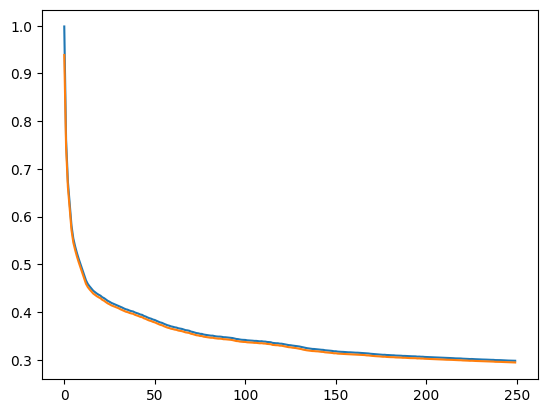


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [100, 202, 305]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [305, 202, 100], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 50}}, 'max_epochs': 250, 'nickname': 'bottleneck_100', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 50, 'decoder_sizes': [100, 202, 305, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=305, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=305, out_features=202, bias=True)
      (3):

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 206 K  | train
2 | decoder       | MLP     | 207 K  | train
--------------------------------------------------
414 K     Trainable params
0         Non-trainable params
414 K     Total params
1.656     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 39.08it/s, v_num=0_1, recon_loss_step=0.254, covariance_loss_step=0.00413, sparsity_loss_step=0.0732, train_loss_step=0.259, recon_loss_epoch=0.254, covariance_loss_epoch=0.00421, sparsity_loss_epoch=0.0725, train_loss_epoch=0.259]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:02<00:00, 38.61it/s, v_num=0_1, recon_loss_step=0.254, covariance_loss_step=0.00413, sparsity_loss_step=0.0732, train_loss_step=0.259, recon_loss_epoch=0.254, covariance_loss_epoch=0.00421, sparsity_loss_epoch=0.0725, train_loss_epoch=0.259]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_100_v1__reconstructed_outputs.csv


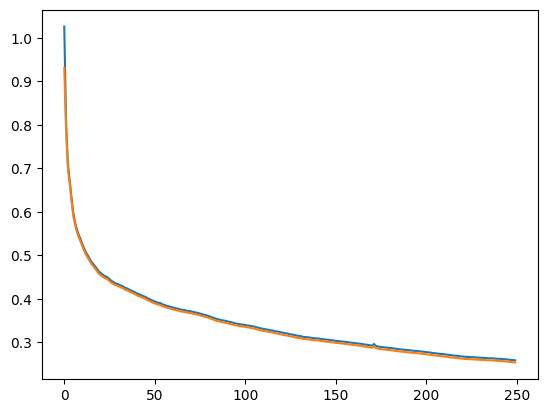


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 221, 314]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [314, 221, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 250, 'nickname': 'bottleneck_128', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/census_data/engcensus_cleaned_zstandardized.parquet'}, 'working_dir': '../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 221, 314, 408], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=408, out_features=314, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=314, out_features=221, bias=True)
      (3):

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 226 K  | train
2 | decoder       | MLP     | 226 K  | train
--------------------------------------------------
453 K     Trainable params
0         Non-trainable params
453 K     Total params
1.813     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/projects/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 

Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 33.13it/s, v_num=0_1, recon_loss_step=0.235, covariance_loss_step=0.00454, sparsity_loss_step=0.0771, train_loss_step=0.240, recon_loss_epoch=0.235, covariance_loss_epoch=0.00485, sparsity_loss_epoch=0.0768, train_loss_epoch=0.241]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|██████████| 100/100 [00:03<00:00, 32.71it/s, v_num=0_1, recon_loss_step=0.235, covariance_loss_step=0.00454, sparsity_loss_step=0.0771, train_loss_step=0.240, recon_loss_epoch=0.235, covariance_loss_epoch=0.00485, sparsity_loss_epoch=0.0768, train_loss_epoch=0.241]
Reconstructed outputs saved to ../AE_outputs/engcensus_all_zstandardized/250epoch_scan_lin/census_geodemo_sparsecov__bottleneck_128_v1__reconstructed_outputs.csv


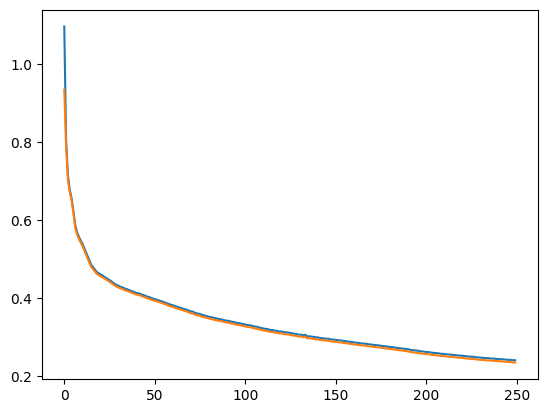

In [5]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparsecov"

# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)

In [11]:
PCA_save_dir =WORKING_DIR = "../AE_outputs/"+data_name+"/PCA/"
os.makedirs(PCA_save_dir, exist_ok=True)
df_scaled.set_index("OA", inplace=True)
n_features = df_scaled.shape[1]


pca = PCA(n_components=n_features - 1) # Fit PCA once with the maximum number of components
transformed = pca.fit_transform(df_scaled)
for n in tqdm(bottleneck_sizes, desc="Processing PCA"):
    save_path = f"{PCA_save_dir}{n}_components.csv"
    #check if the file already exists
    # if os.path.exists(save_path):
    #     print(f"File {save_path} already exists. Skipping...")
    #     continue
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    #reconstruct the data
    #save the reconstructed data
    pd.DataFrame(reconstructed_pca, index=df_scaled.index, columns=df_scaled.columns).to_csv(save_path)





Processing PCA: 100%|██████████| 8/8 [13:30<00:00, 101.37s/it]
